# 04 · Retrospective benchmark and production handoff

This notebook evaluates the **exact completed feature and model runs from 02 and 03**. It refits the predeclared men's ranking-logistic and women's logistic anchors for 2022–2025, with all choices frozen from pre-2022 development predictions. These years have already been consumed: this is a retrospective comparison, not an untouched holdout.

`MODE = "review"` verifies and displays committed evidence. `MODE = "train"` runs the 16 annual benchmark fits with verified checkpoints. Neither mode generates a 2026 submission; the final export cell remains a separate, default-off option.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from march_mania.notebook_support import table, style
from march_mania.runtime import digest
from march_mania.publication.workflow import benchmark_evidence, benchmark_stage, execution_mode

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
MODE = execution_mode()  # Set "train" to evaluate the current completed 02/03 runs.
if MODE == "train":
    benchmark_stage(ROOT)
FINAL, record = benchmark_evidence(ROOT)
summary = record["summary"]
assert summary["status"] == "completed" and not summary["future_labels_used"]
assert not summary["submission_generated"]
style()
display(Markdown(f"**{summary['model_fits']} annual fits · {summary['physical_games']} physical games · retrospective 2022–2025 benchmark**"))
table(pd.DataFrame([{"Stage": stage, "Fingerprint": record["manifest"]["inputs"][key]}
                    for stage, key in [("02 features", "feature_fingerprint"), ("03 models", "model_fingerprint")]]))


**16 annual fits · 536 physical games · retrospective 2022–2025 benchmark**

Stage,Fingerprint
02 features,199b4c00a8b59393a1290727ca6e0e5b9f9bbc5a17db18e1b02354229e5eed89
03 models,20e69d30dc746f39f9395f96d1ff13d7a24cb0a7998fd096a0409c31fa7d7193


## Frozen recipe and training boundaries

The model families and identity calibration follow the predeclared inference contract; notebook 03 separately compares all supported families. Within each logistic family, the feature block and regularization use only saved 2016–2021 development predictions. Every evaluation season is fitted on earlier seasons only. The seed-free route removes every seed-dependent input and uses the same regularization.


In [2]:
recipe = json.loads((FINAL / "recipe.json").read_text())
fits = json.loads((FINAL / "fit_audits.json").read_text())
assert all(r["training_max_season"] < r["prediction_season"] < 2026 for r in fits)
table(pd.DataFrame([{"Tournament": r["gender"], "Route": r["route"],
                     "Evaluated season": r["prediction_season"],
                     "Candidate": r["candidate"]["name"],
                     "Candidates": r["candidate_count"], "Retained": r["retained_count"],
                     "Training games": r["training_games"],
                     "Last training season": r["training_max_season"]} for r in fits]))


Tournament,Route,Evaluated season,Candidate,Candidates,Retained,Training games,Last training season
M,seeded,2022,rank_logistic_1,19,16,535,2021
M,seed_free,2022,rank_logistic_1,18,15,535,2021
M,seeded,2023,rank_logistic_1,19,16,602,2022
M,seed_free,2023,rank_logistic_1,18,15,602,2022
M,seeded,2024,rank_logistic_1,19,16,669,2023
M,seed_free,2024,rank_logistic_1,18,15,669,2023
M,seeded,2025,rank_logistic_1,19,16,736,2024
M,seed_free,2025,rank_logistic_1,18,15,736,2024
W,seeded,2022,logistic_conference_1,18,16,504,2021
W,seed_free,2022,logistic_conference_1,17,15,504,2021


## Retrospective 2022–2025 benchmark

Each season is predicted using only earlier seasons, with the same frozen recipe. The seed-free route is also evaluated on the same tournament games to expose the value of seed information. Its tournament performance does not prove generalization to teams that never qualified.

**Game-weighted Brier** averages every game's squared error. **Mean season Brier** weights seasons equally. Log loss, ROC AUC, average precision and calibration error provide complementary diagnostics. The benchmark was consumed in prior work and is not used to replace the frozen recipe.

The expanded seeded anchors score **0.198288 for men and 0.146881 for women**. The previous 124-feature anchors scored 0.198014 and 0.138599. Neither improves here, and the women regress materially. The new conference block’s development minimum did not establish better benchmark performance. This negative result remains visible without reselecting on the consumed benchmark.

Gender,route,games,brier,mean_season_brier,log_loss,roc_auc,average_precision,ece_10_bins
M,seed_free,268,0.197639,0.197639,0.578065,0.754443,0.795248,0.053146
M,seeded,268,0.198288,0.198288,0.579068,0.751196,0.794644,0.048059
W,seed_free,268,0.148550,0.148550,0.441682,0.870848,0.838521,0.082929
W,seeded,268,0.146881,0.146881,0.438468,0.871468,0.840123,0.066548


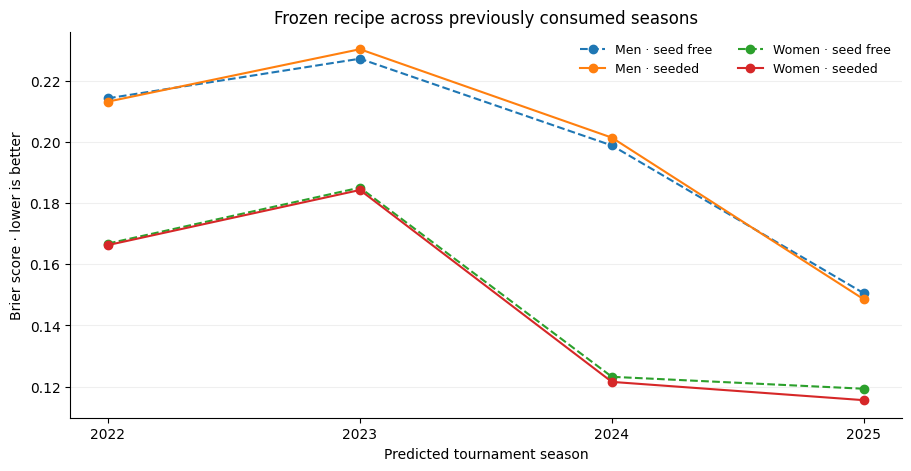

In [3]:
current = pd.read_csv(FINAL / "metrics.csv")
seasonal = pd.read_csv(FINAL / "metrics_by_season.csv")
table(current[["Gender", "route", "games", "brier", "mean_season_brier",
               "log_loss", "roc_auc", "average_precision", "ece_10_bins"]])
fig, ax = plt.subplots(figsize=(9, 4.6), constrained_layout=True)
for (gender, route), group in seasonal.groupby(["Gender", "route"]):
    group = group.sort_values("Season")
    ax.plot(group.Season, group.brier, marker="o",
            linestyle="-" if route == "seeded" else "--",
            label=f"{'Men' if gender == 'M' else 'Women'} · {route.replace('_',' ')}")
ax.set(title="Frozen recipe across previously consumed seasons",
       xlabel="Predicted tournament season", ylabel="Brier score · lower is better",
       xticks=[2022, 2023, 2024, 2025])
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=.2)
ax.legend(frameon=False, ncol=2, fontsize=9)
plt.show()

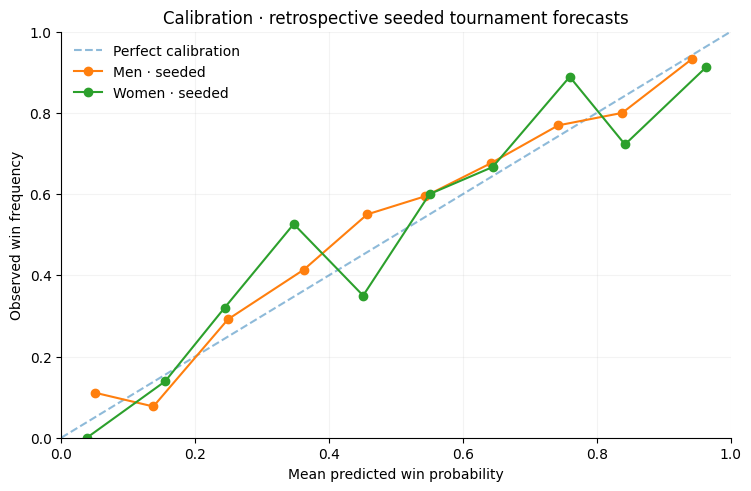

Points summarize ten probability bins. Small bin counts and only four seasons limit precision; proximity to the diagonal is not proof of future calibration. No curve here is used for post-benchmark tuning.

In [4]:
reliability = pd.read_csv(FINAL / "reliability.csv")
fig, ax = plt.subplots(figsize=(7.4, 4.8), constrained_layout=True)
ax.plot([0,1], [0,1], linestyle="--", alpha=.5, label="Perfect calibration")
for gender, group in reliability.loc[reliability.route.eq("seeded")].groupby("Gender"):
    ax.plot(group.predicted, group.observed, marker="o",
            label=f"{'Men' if gender == 'M' else 'Women'} · seeded")
ax.set(title="Calibration · retrospective seeded tournament forecasts",
       xlabel="Mean predicted win probability", ylabel="Observed win frequency",
       xlim=(0,1), ylim=(0,1))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=.15)
ax.legend(frameon=False)
plt.show()
display(Markdown("Points summarize ten probability bins. Small bin counts and only four "
                 "seasons limit precision; proximity to the diagonal is not proof of "
                 "future calibration. No curve here is used for post-benchmark tuning."))

## Evidence and reproducibility

Each of the 16 estimators and 16 prediction batches is checkpointed after its output hashes are recorded. The portable archive preserves the complete audit, development predictions, fitted models, source and feature matrix. The independent model-search recovery test in notebook 03 reports whether a fresh directory reproduces forecasts without repeating fits.

Historical final-submission evidence remains under `reports/final_predictions/` with its original 124-feature lineage. It is not evidence for this expanded experiment.


In [5]:
archive = record["archive"]
assert archive["status"] == "uploaded"
table(pd.DataFrame([{"Run": summary["fingerprint"], "Archive SHA-256": archive["sha256"],
                     "Bytes": archive["bytes"], "Version": archive["version_id"],
                     "Submission generated": summary["submission_generated"],
                     "Kaggle upload sent": summary["kaggle_submission_sent"]}]))
display(Markdown("The archive and exact upstream fingerprints make this evaluation reproducible. The benchmark is descriptive; it does not authorize tuning on these seasons."))


Run,Archive SHA-256,Bytes,Version,Submission generated,Kaggle upload sent
2680bf105e369bbeb1b937d504c8b4f4c8c3772895869acc8b7c5decd0fb9b74,4e243437990b48311238286a9585c83997ea84915a090c44a2ca711845965a01,18070392,Qb.wbPTCFOCmVxk6_C_1_7i32I3T.GeZ,False,False


The archive and exact upstream fingerprints make this evaluation reproducible. The benchmark is descriptive; it does not authorize tuning on these seasons.

## Fifty-file production release

Ten men's procedures crossed with five women's procedures produced **50 distinct complete files**, each containing **132,133 matchups**. Choices and blend weights were frozen from explored pre-2022 development predictions; final training uses 2013–2025, excluding 2020. The reference remains `m_rank_logistic__w_logistic`.

These are retrospective sensitivity candidates. Fifty outputs do not establish fifty independent discoveries or better forecasting accuracy. The **127,577 pairs requiring seed-free features lack matched tournament OOF validation**; their coverage must not be confused with the seeded benchmark above.

This review reads public receipts and file hashes. Restoration and generation remain off by default.


In [6]:
from march_mania.publication import production, production_inputs, production_release

PRODUCTION = ROOT / "reports/prediction_production"
production_summary = production_release.check(ROOT)
production_manifest = pd.read_csv(PRODUCTION / "submission_manifest.csv")
production_archive = json.loads((PRODUCTION / "archive.json").read_text())
production_recovery = json.loads((PRODUCTION / "s3_recovery.json").read_text())
assert production_recovery["archive"] == production_archive
assert production_recovery["checkpoints_reused"] == 344
assert production_recovery["new_fits"] == production_recovery["new_tasks"] == 0
assert production_recovery["submission_files_byte_identical"] == len(production_manifest)
table(pd.DataFrame([{
    "Complete files": production_summary["submission_files"],
    "Rows per file": production_summary["rows_per_file"],
    "Fitted models": production_summary["fitted_models"],
    "Restored checkpoints": production_recovery["checkpoints_reused"],
    "New fits during recovery": production_recovery["new_fits"],
    "Last training season": production_summary["training_max_season"],
    "Kaggle upload sent": production_summary["kaggle_submission_sent"],
}]))
table(pd.read_csv(PRODUCTION / "routes.csv"))
REFERENCE_CANDIDATE = "m_rank_logistic__w_logistic"
table(production_manifest.loc[production_manifest.candidate_id.eq(REFERENCE_CANDIDATE)])
display(Markdown("[All fifty checksums](../reports/prediction_production/submission_manifest.csv) · [Frozen recipe](../reports/prediction_production/recipe.json) · [Remote recovery proof](../reports/prediction_production/s3_recovery.json) · [Employer walkthrough](../docs/employer_walkthrough.md)"))


Complete files,Rows per file,Fitted models,Restored checkpoints,New fits during recovery,Last training season,Kaggle upload sent
50,132133,33,344,0,2025,False


Gender,feature_route,rows
M,seed_free,64152
M,seeded,2278
W,seed_free,63425
W,seeded,2278


candidate_id,path,rows,bytes,sha256
m_rank_logistic__w_logistic,csv_m_rank_logistic__w_logistic/submission.csv,132133,4635537,a4b4e17f1e6f3f2c938e83949872fd463eb3af1fea3ebeea524bc6d745bd51ed


[All fifty checksums](../reports/prediction_production/submission_manifest.csv) · [Frozen recipe](../reports/prediction_production/recipe.json) · [Remote recovery proof](../reports/prediction_production/s3_recovery.json) · [Employer walkthrough](../docs/employer_walkthrough.md)

## Restore the completed files, or run the frozen recipe

Set `RESTORE_PRODUCTION = True` to retrieve the exact private S3 version, verify all saved tasks and display a download link. This needs access to the existing bucket but **no raw inputs or fitting**. Choose any `candidate_id` from the manifest; the default is the reference.

To execute the production pipeline, set `GENERATE_PORTFOLIO = True` instead. It verifies/restores immutable input members and calls the checkpointed runner. An identical completed release reuses its archived checkpoints. Changed production source or environment creates a new run and can require real fitting. Restore and generation are mutually exclusive; both default to off.

Files remain under `outputs/prediction_production/<fingerprint>/csv_<candidate>/submission.csv`. No option sends files to Kaggle.


After either action, a second download provides all fifty CSVs in `submissions/prediction_portfolio.zip`, together with their manifest and frozen recipe. Every CSV keeps its recorded bytes. A verified packaging checkpoint is reused on repeat requests.

In [7]:
from IPython.display import HTML

RESTORE_PRODUCTION = False
GENERATE_PORTFOLIO = False
SELECTED_CANDIDATE = "m_rank_logistic__w_logistic"
if RESTORE_PRODUCTION and GENERATE_PORTFOLIO:
    raise ValueError("Choose either archive restoration or production execution")
if SELECTED_CANDIDATE not in set(production_manifest.candidate_id):
    raise ValueError("Choose a candidate_id from the public submission manifest")
if RESTORE_PRODUCTION or GENERATE_PORTFOLIO:
    destination = ROOT / "outputs/prediction_production"
    if RESTORE_PRODUCTION:
        production_run = production_release.recover(ROOT, destination)
    else:
        production_input_dir = ROOT / "outputs/production_inputs"
        try:
            production_inputs.verify(ROOT, production_input_dir)
        except FileNotFoundError:
            production_inputs.restore(ROOT, production_input_dir)
        production_run = production.run(ROOT, production_input_dir, destination)
    verified_files = production_release.verify_tasks(production_run, production_run.name)
    selected = pd.read_csv(production_run / "publication/submission_manifest.csv")
    selected = selected.loc[selected.candidate_id.eq(SELECTED_CANDIDATE)].iloc[0]
    selected_path = production_run / selected.path
    assert digest(selected_path) == verified_files[SELECTED_CANDIDATE]
    import runpy
    delivery = runpy.run_path(str(ROOT / "scripts/deliver_predictions.py"))
    downloads = delivery["package"](ROOT, production_run)
    display(HTML('<a href="../submissions/prediction_portfolio.zip" '
                 'download="prediction_portfolio.zip">Download all 50 prediction files</a>'))
    relative_path = selected_path.relative_to(ROOT).as_posix()
    display(Markdown(f"**{len(verified_files)} complete files verified.** Selected: `{SELECTED_CANDIDATE}`. SHA-256: `{verified_files[SELECTED_CANDIDATE]}`. No Kaggle upload was sent."))
    display(HTML(f'<a href="../{relative_path}" download="{SELECTED_CANDIDATE}.csv">Download selected CSV</a>'))
else:
    display(Markdown("**Restoration and generation are off.** Set `RESTORE_PRODUCTION = True` to retrieve the completed release without fitting."))


**Restoration and generation are off.** Set `RESTORE_PRODUCTION = True` to retrieve the completed release without fitting.

## Optional single-recipe generation from your current 02/03 run

This separate control uses current local research runs. To retrieve the completed fifty-file release, use restoration above.

First run **02 and 03 with `MODE = "train"`**, using your current raw inputs and matching checkpoints. Then set `GENERATE_SUBMISSION = True` below and run the cell. It calls real model refitting/inference when needed, verifies exact template order, probability bounds and team orientation, then writes **`submissions/submission.csv`** atomically. Matching successful fits are reused. It requires the existing AWS role to retain durable checkpoints.

The cell refuses stale feature or model inputs rather than exporting probabilities from an unrelated saved experiment. The recipe is explicit in `configs/inference.json`; the existing logistic recipe is a frozen baseline, not a claim that it wins every later research comparison.

Use the displayed link, or find `submissions/submission.csv` in JupyterLab's file browser and choose **Download**. You decide whether to upload it to Kaggle. There is no upload call in this workflow. This notebook does not create a CSV in review mode.

In [8]:
from IPython.display import HTML
from march_mania.publication.workflow import generate_submission

GENERATE_SUBMISSION = False  # Change to True only when YOU are ready to generate locally.
if GENERATE_SUBMISSION:
    SUBMISSION = generate_submission(ROOT)
    display(Markdown(f"**Your file is ready:** `submissions/submission.csv`  \nSHA-256: `{digest(SUBMISSION)}`. No Kaggle upload was sent."))
    display(HTML('<a href="../submissions/submission.csv" download="submission.csv">Download your submission.csv</a>'))
else:
    display(Markdown("**Export is off.** Set `GENERATE_SUBMISSION = True` to generate and download your own file after 02/03 training."))

**Export is off.** Set `GENERATE_SUBMISSION = True` to generate and download your own file after 02/03 training.

Sources: [official competition and evaluation](https://www.kaggle.com/competitions/march-machine-learning-mania-2026) · exact current benchmark manifests in `reports/benchmark/` · historical [score log](../reports/submission_portfolio/). Local evaluation includes play-ins and is not identical to Kaggle's scored population.
